L = 2, N = 1, dim = 2
static J(V0) = 43.3228 Hz, tilt Delta = 835 Hz, drive f = 835 Hz
initial state = (0, 1) (center site 1)
final norm = 0.999999981812268
L = 2, N = 1, dim = 2
initial state = (0, 1)  (center site 1)
final norm = 0.9999999997888561


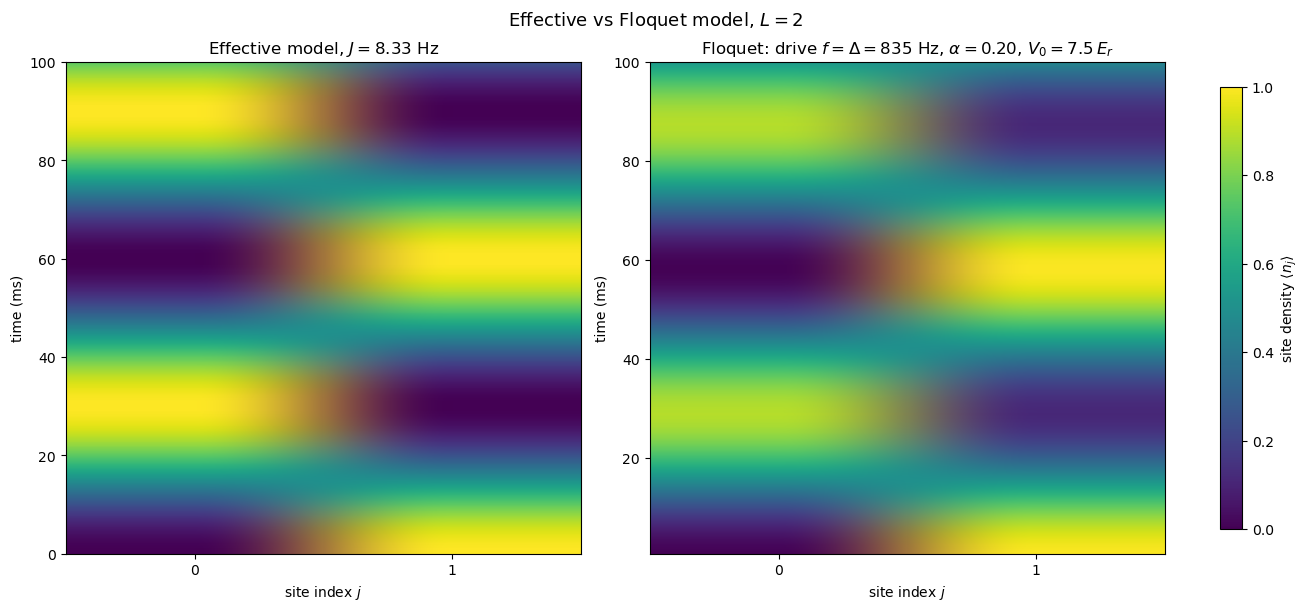

saved combined figure -> compare_heatmaps.png


In [13]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =============================================================
# 1D SINGLE-PARTICLE tunneling with Floquet engineering.
#   - tilt Delta (Wannier-Stark) ON
#   - lattice-depth modulation drive (nonlinear V->J), as in test5
#   - drive AT the tilt frequency f = Delta_hz  -> photon-assisted tunneling
#   - density heatmap is AVERAGED over one Floquet period
# =============================================================

# -----------------------------
# System
# -----------------------------
L = 2
N = 1

U_hz     = 285.0        # irrelevant for N=1, kept for generality
Delta_hz = 835.0        # tilt per site (Hz)
TIME_EVOLVE = 0.1       # total evolution time (s)

# Line-cut option: probability (site density) vs time for specified site(s).
# Set to a list of site indices, e.g. [0] or [0, 1]; None/[] to skip.
PLOT_SITES = []

# Resonance-scan option: sweep drive frequency and plot max transfer at each.
# Set SCAN_FREQ = True to run the scan (skips nothing; runs after the time trace).
SCAN_FREQ        = False
SCAN_SPAN_HZ     = 60.0    # +/- range around the nominal drive frequency
SCAN_N_POINTS    = 41
SCAN_N_PERIODS   = 400     # evolution length per frequency (drive periods)
SCAN_TARGET_SITE = None    # site whose max occupation = "transfer"; None -> auto

# --- lattice-depth modulation drive (single tone at the tilt frequency) ------
V0           = 0.75 * 10.0             # static lattice depth (Er)
alpha        = [0.2]            # depth modulation amplitude(s)
f_drive_list = [Delta_hz]       # DRIVE AT THE TILT FREQUENCY
# -----------------------------------------------------------------------------

J_OUTPUT_UNITS = "Hz"
E_R_HZ = 1.0

twopi = 2.0 * np.pi

# -----------------------------
# Lattice depth -> tunneling (same converter as test5)
# -----------------------------
def V_to_J(V):
    V = np.asarray(V, dtype=float)
    a = 284.4; b = -0.2922; c = 30.69; d = -0.1304   # Er in, Hz out
    return a*np.exp(b*V) + c*np.exp(d*V)

def J_angular(V):
    Jval = V_to_J(V)
    if J_OUTPUT_UNITS == "Hz":      return twopi*Jval
    elif J_OUTPUT_UNITS == "angular": return Jval
    elif J_OUTPUT_UNITS == "Er":    return twopi*E_R_HZ*Jval
    else: raise ValueError("bad J_OUTPUT_UNITS")

alpha        = np.atleast_1d(np.asarray(alpha, dtype=float))
f_drive_list = np.atleast_1d(np.asarray(f_drive_list, dtype=float))
if alpha.shape != f_drive_list.shape:
    raise ValueError("alpha and f_drive_list must have the same length.")

U     = twopi * U_hz
Delta = twopi * Delta_hz
omega = twopi * f_drive_list
f_ref_hz = f_drive_list.min()
T_ref = 1.0 / f_ref_hz

# -----------------------------
# Single-particle basis
# -----------------------------
def generate_basis(L, N):
    return [tuple(occ) for occ in itertools.product(range(N + 1), repeat=L)
            if sum(occ) == N]
basis = generate_basis(L, N)
index = {s: i for i, s in enumerate(basis)}
dim   = len(basis)
print("L = %d, N = %d, dim = %d" % (L, N, dim))
print("static J(V0) = %.4f Hz, tilt Delta = %.0f Hz, drive f = %.0f Hz"
      % (J_angular(V0)/twopi, Delta_hz, f_ref_hz))

# -----------------------------
# Hamiltonian pieces:
#   H_diag carries the tilt (and U, =0 effect for N=1).
#   H_hop_unit carries unit-J hopping; scaled by J_angular(V(t)) at runtime.
# -----------------------------
def build_diag():
    H = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        n = np.array(state)
        H[a, a] = 0.5*U*np.sum(n*(n-1)) + Delta*np.sum(np.arange(L)*n)
    return H

def build_hop_unit():
    H = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        n = np.array(state)
        for j in range(L-1):
            if n[j] > 0:
                new = n.copy(); amp = np.sqrt(n[j])*np.sqrt(n[j+1]+1)
                new[j]-=1; new[j+1]+=1
                H[index[tuple(new)], a] += -amp
            if n[j+1] > 0:
                new = n.copy(); amp = np.sqrt(n[j+1])*np.sqrt(n[j]+1)
                new[j+1]-=1; new[j]+=1
                H[index[tuple(new)], a] += -amp
    return H

H_diag     = build_diag()
H_hop_unit = build_hop_unit()

# -----------------------------
# Site-density operators
# -----------------------------
n_ops = []
for site in range(L):
    op = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        op[a, a] = state[site]
    n_ops.append(op)

# -----------------------------
# Initial state: particle at center site
# -----------------------------
center = L // 2
init_state = tuple(1 if s == center else 0 for s in range(L))
psi0 = np.zeros(dim, dtype=complex)
psi0[index[init_state]] = 1.0
print("initial state =", init_state, "(center site %d)" % center)

# -----------------------------
# Depth modulation and evolution
# -----------------------------
def V_of_t(t):
    return V0 * (1.0 + np.sum(alpha * np.cos(omega * t)))

def rhs(t, psi):
    Jt = J_angular(V_of_t(t))
    return -1j * (H_diag + Jt * H_hop_unit).dot(psi)

# Sample densely and uniformly so an integer number of samples spans one drive
# period -> clean one-period (Floquet) average.
samples_per_period = 40
n_periods_total = int(round(TIME_EVOLVE / T_ref))
n_times = n_periods_total * samples_per_period + 1
times = np.linspace(0.0, n_periods_total * T_ref, n_times)

sol = solve_ivp(rhs, (times[0], times[-1]), psi0, t_eval=times,
                rtol=1e-10, atol=1e-10, method="RK45")
psis = sol.y.T
print("final norm =", np.linalg.norm(psis[-1]))

# instantaneous density[t, site]
density = np.zeros((len(times), L))
for ti, p in enumerate(psis):
    for site in range(L):
        density[ti, site] = np.vdot(p, n_ops[site].dot(p)).real

times_ms = 1000.0 * times    # raw-grid times in ms

# -----------------------------
# Floquet (one-period) average of the density, per site.
# Boxcar of width = samples_per_period via 'valid' convolution.
# -----------------------------
w = samples_per_period
kernel = np.ones(w) / w
density_avg = np.empty((len(times) - w + 1, L))
for site in range(L):
    density_avg[:, site] = np.convolve(density[:, site], kernel, mode="valid")
t_avg = times[(w-1)//2 : (w-1)//2 + density_avg.shape[0]]
times_ms_avg = 1000.0 * t_avg

# -----------------------------
# Line cuts: probability on specified site(s) vs time.
# -----------------------------
if PLOT_SITES:
    plt.figure(figsize=(8, 5))
    for site in PLOT_SITES:
        if site < 0 or site >= L:
            print("warning: site %d out of range [0, %d], skipping" % (site, L-1))
            continue
        # raw (micromotion) faint
        plt.plot(times_ms, density[:, site], lw=0.8, alpha=0.3,
                 color="C%d" % (site % 10))
        # Floquet-averaged envelope
        plt.plot(times_ms_avg, density_avg[:, site], lw=1.8,
                 color="C%d" % (site % 10),
                 label=r"site $j=%d$ (Floquet-avg)" % site)
    plt.xlabel("time (ms)")
    plt.ylabel(r"probability $\langle n_j \rangle$")
    plt.ylim(0, 1.05)
    plt.title(r"Site occupation vs time (driven), drive $f=\Delta=%.0f$ Hz, $\alpha=%.2f$"
              % (f_ref_hz, alpha[0]))
    plt.legend()
    plt.tight_layout()
    plt.savefig("testF0_sites.png", dpi=120)
    plt.show()

# =============================================================
# RESONANCE SCAN: maximum transfer vs drive frequency
# =============================================================
if SCAN_FREQ:
    if SCAN_TARGET_SITE is not None:
        target_site = SCAN_TARGET_SITE
    elif L == 2:
        target_site = 1 - center
    else:
        target_site = 0 if center > (L-1)/2 else (L-1)
    print("\n[scan] target site for transfer = %d" % target_site)

    f_nominal = f_ref_hz
    scan_freqs = np.linspace(f_nominal - SCAN_SPAN_HZ,
                             f_nominal + SCAN_SPAN_HZ, SCAN_N_POINTS)

    def max_transfer(f_drive):
        om = twopi * f_drive
        def rhs_scan(t, psi):
            Jt = J_angular(V0 * (1.0 + np.sum(alpha * np.cos(om * t))))
            return -1j * (H_diag + Jt * H_hop_unit).dot(psi)
        T = 1.0 / f_drive
        t_end = SCAN_N_PERIODS * T
        ts = np.linspace(0.0, t_end, SCAN_N_PERIODS * 8 + 1)
        sol = solve_ivp(rhs_scan, (0.0, t_end), psi0, t_eval=ts,
                        rtol=1e-9, atol=1e-9, method="RK45")
        occ = np.abs(sol.y[index[tuple(1 if s == target_site else 0
                                       for s in range(L))]])**2
        return occ.max()

    peak = np.array([max_transfer(f) for f in scan_freqs])

    f_best = scan_freqs[np.argmax(peak)]
    print("[scan] nominal drive f = %.2f Hz" % f_nominal)
    print("[scan] peak transfer at f = %.2f Hz  (max transfer = %.4f)"
          % (f_best, peak.max()))
    print("[scan] offset from bare Delta = %+.2f Hz" % (f_best - Delta_hz))

    plt.figure(figsize=(8, 5))
    plt.plot(scan_freqs, peak, "o-", ms=4)
    plt.axvline(Delta_hz, color="k", ls="--", lw=1,
                label=r"$\Delta = %.0f$ Hz" % Delta_hz)
    plt.axvline(f_nominal, color="C1", ls=":", lw=1.5,
                label=r"nominal drive = %.1f Hz" % f_nominal)
    plt.axvline(f_best, color="C3", ls="-", lw=1,
                label=r"peak at %.1f Hz" % f_best)
    plt.xlabel("drive frequency (Hz)")
    plt.ylabel(r"max transfer to site %d" % target_site)
    plt.ylim(0, 1.05)
    plt.title(r"Resonance scan: $\alpha=%.2f$, $V_0=%.1f\,E_r$, $\Delta=%.0f$ Hz"
              % (alpha[0], V0, Delta_hz))
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("testF0_scan.png", dpi=120)
    plt.show()

# ===============================================================
# No floquet (EFFECTIVE) model
# ===============================================================
J_hz = (V_to_J(V0 * (1 - alpha[0])) - V_to_J(V0 * (1 + alpha[0]))) / 4.0    # estimated tunneling strength (Hz)
PLOT_SITES = []

J = twopi * J_hz    # angular frequency (rad/s)

# basis is identical; reuse generate_basis for clarity / independence
basis = generate_basis(L, N)
index = {s: i for i, s in enumerate(basis)}
dim   = len(basis)

print("L = %d, N = %d, dim = %d" % (L, N, dim))

# -----------------------------
# Hamiltonian: nearest-neighbour hopping only (effective static model).
# -----------------------------
def build_hop():
    H = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        n = np.array(state)
        for j in range(L-1):
            if n[j] > 0:
                new = n.copy(); amp = np.sqrt(n[j])*np.sqrt(n[j+1]+1)
                new[j]-=1; new[j+1]+=1
                H[index[tuple(new)], a] += -J*amp
            if n[j+1] > 0:
                new = n.copy(); amp = np.sqrt(n[j+1])*np.sqrt(n[j]+1)
                new[j+1]-=1; new[j]+=1
                H[index[tuple(new)], a] += -J*amp
    return H

H = build_hop()

# Site-density operators
n_ops = []
for site in range(L):
    op = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        op[a, a] = state[site]
    n_ops.append(op)

# Initial state: particle at the center site
center = L // 2
init_state = tuple(1 if s == center else 0 for s in range(L))
psi0 = np.zeros(dim, dtype=complex)
psi0[index[init_state]] = 1.0
print("initial state =", init_state, " (center site %d)" % center)

# Time evolution
def rhs_eff(t, psi):
    return -1j * H.dot(psi)

n_times = 400
times_eff = np.linspace(0.0, TIME_EVOLVE, n_times)
sol = solve_ivp(rhs_eff, (0.0, TIME_EVOLVE), psi0, t_eval=times_eff,
                rtol=1e-10, atol=1e-10, method="RK45")
psis = sol.y.T
print("final norm =", np.linalg.norm(psis[-1]))

# density[t, site] for the effective model
density_eff = np.zeros((len(times_eff), L))
for ti, p in enumerate(psis):
    for site in range(L):
        density_eff[ti, site] = np.vdot(p, n_ops[site].dot(p)).real

times_ms_eff = 1000.0 * times_eff

if PLOT_SITES:
    plt.figure(figsize=(8, 5))
    for site in PLOT_SITES:
        if site < 0 or site >= L:
            print("warning: site %d out of range [0, %d], skipping" % (site, L-1))
            continue
        plt.plot(times_ms_eff, density_eff[:, site], lw=1.8,
                 label=r"site $j=%d$" % site)
    plt.xlabel("time (ms)")
    plt.ylabel(r"probability $\langle n_j \rangle$")
    plt.ylim(0, 1.05)
    plt.title(r"Site occupation vs time, $L=%d$, $J=%.2f$ Hz" % (L, J_hz))
    plt.legend()
    plt.tight_layout()
    plt.savefig("test_J_0_sites.png", dpi=120)
    plt.show()

# ===============================================================
# COMBINED FIGURE: effective (left) vs Floquet (right)
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)

# --- Left: effective (no-Floquet) static model ---
im0 = axes[0].imshow(density_eff, aspect="auto", origin="lower",
                     extent=[-0.5, L-0.5, times_ms_eff[0], times_ms_eff[-1]],
                     cmap="viridis", vmin=0.0, vmax=1.0)
axes[0].set_xlabel("site index $j$")
axes[0].set_ylabel("time (ms)")
axes[0].set_xticks(range(L))
axes[0].set_title(r"Effective model, $J=%.2f$ Hz" % J_hz)

# --- Right: Floquet-averaged driven model ---
im1 = axes[1].imshow(density_avg, aspect="auto", origin="lower",
                     extent=[-0.5, L-0.5, times_ms_avg[0], times_ms_avg[-1]],
                     cmap="viridis", vmin=0.0, vmax=1.0)
axes[1].set_xlabel("site index $j$")
axes[1].set_ylabel("time (ms)")
axes[1].set_xticks(range(L))
axes[1].set_title(r"Floquet: drive $f=\Delta=%.0f$ Hz, $\alpha=%.2f$, $V_0=%.1f\,E_r$"
                  % (f_ref_hz, alpha[0], V0))

cbar = fig.colorbar(im1, ax=axes, label=r"site density $\langle n_j\rangle$",
                    shrink=0.9)

fig.suptitle(r"Effective vs Floquet model, $L=%d$" % L, fontsize=13)
fig.savefig("compare_heatmaps.png", dpi=120)
plt.show()
print("saved combined figure -> compare_heatmaps.png")